In [2]:
# Geospatial data handling
import geopandas as gpd

# Plotting
import matplotlib.pyplot as plt

# Geometric operations (used internally by GeoPandas, but can also be used explicitly)
from shapely.geometry import Point, Polygon

# For coordinate transformations (used internally by GeoPandas, but can also be used explicitly)
import pyproj

# Used by Matplotlib to plot Shapely objects (often needed when using complex geometries)
from descartes import PolygonPatch

# Data manipulation (often used with GeoPandas)
import pandas as pd

# # For adding basemap tiles (optional, for enhanced visualization)
# import contextily as ctx


In [7]:
# Define the path to your CSV file
csv_path = r'C:\Users\Alexander\Documents\GitHub\Diplomado_PUCP\_data\Datos_panel_distritos.csv'

# Read the CSV file using pandas
df_covid = pd.read_csv(csv_path)

# Display the first few rows of the DataFrame
df_covid


,Código,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,3,2020,0,0,16
1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,4,2020,47,0,5
2,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,5,2020,165,3,11
3,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,6,2020,119,2,15
4,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,7,2020,175,2,8
...,...,...,...,...,...,...,...,...,...
40406,250401,UCAYALI,PURUS,PURUS,9,2021,0,0,0
40407,250401,UCAYALI,PURUS,PURUS,10,2021,0,0,0
40408,250401,UCAYALI,PURUS,PURUS,11,2021,0,0,2
40409,250401,UCAYALI,PURUS,PURUS,12,2021,0,0,0


In [8]:
import geopandas as gpd

# Path to the shapefile directory
shapefile_path = "C:\\Users\\Alexander\\Documents\\GitHub\\Diplomado_PUCP\\_data\\shape_file"

# Read the shapefile
gdf = gpd.read_file(shapefile_path + "\\DISTRITOS.shp")

# Print the first few rows of the GeoDataFrame
gdf

,IDDPTO,DEPARTAMEN,IDPROV,PROVINCIA,IDDIST,DISTRITO,CAPITAL,CODCCPP,AREA,FUENTE,geometry
0,10,HUANUCO,1009,PUERTO INCA,100902,CODO DEL POZUZO,CODO DEL POZUZO,0001,1,INEI,"POLYGON ((-75.31797 -9.29529, -75.31710 -9.297..."
1,10,HUANUCO,1009,PUERTO INCA,100904,TOURNAVISTA,TOURNAVISTA,0001,1,INEI,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,25,UCAYALI,2503,PADRE ABAD,250305,ALEXANDER VON HUMBOLDT,ALEXANDER VON HUMBOLDT,0001,1,INEI,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,25,UCAYALI,2503,PADRE ABAD,250302,IRAZOLA,SAN ALEJANDRO,0001,1,INEI,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,25,UCAYALI,2503,PADRE ABAD,250304,NESHUYA,MONTE ALEGRE,0001,1,INEI,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...,...,...,...,...,...,...,...,...,...
1868,10,HUANUCO,1006,LEONCIO PRADO,100608,CASTILLO GRANDE,CASTILLO GRANDE,0001,1,INEI,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,10,HUANUCO,1006,LEONCIO PRADO,100609,PUEBLO NUEVO,PUEBLO NUEVO,0001,1,INEI,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,10,HUANUCO,1006,LEONCIO PRADO,100610,SANTO DOMINGO DE ANDA,PACAE,0001,1,INEI,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,21,PUNO,2111,SAN ROMAN,211105,SAN MIGUEL,SAN MIGUEL,0001,1,INEI,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


In [20]:
gdf['IDDIST'] = gdf['IDDIST'].astype(int)

In [22]:
import pandas as pd

# Ensure both dataframes have the same column name for district identifier
if 'Código' in df_covid.columns:
    df_covid = df_covid.rename(columns={'Código': 'IDDIST'})

# Merge the dataframes, using 'IDDIST' as the key and specifying 'left' join to keep all rows from df_covid
merged_gdf = gdf.merge(df_covid, on='IDDIST', how='left')
merged_gdf

,IDDPTO,DEPARTAMEN,IDPROV,PROVINCIA,IDDIST,DISTRITO,CAPITAL,CODCCPP,AREA,FUENTE,geometry,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
0,10,HUANUCO,1009,PUERTO INCA,100902,CODO DEL POZUZO,CODO DEL POZUZO,0001,1,INEI,"POLYGON ((-75.31797 -9.29529, -75.31710 -9.297...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,3.0,2020.0,0.0,0.0,3.0
1,10,HUANUCO,1009,PUERTO INCA,100902,CODO DEL POZUZO,CODO DEL POZUZO,0001,1,INEI,"POLYGON ((-75.31797 -9.29529, -75.31710 -9.297...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,4.0,2020.0,0.0,1.0,2.0
2,10,HUANUCO,1009,PUERTO INCA,100902,CODO DEL POZUZO,CODO DEL POZUZO,0001,1,INEI,"POLYGON ((-75.31797 -9.29529, -75.31710 -9.297...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,5.0,2020.0,1.0,0.0,2.0
3,10,HUANUCO,1009,PUERTO INCA,100902,CODO DEL POZUZO,CODO DEL POZUZO,0001,1,INEI,"POLYGON ((-75.31797 -9.29529, -75.31710 -9.297...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,6.0,2020.0,7.0,0.0,1.0
4,10,HUANUCO,1009,PUERTO INCA,100902,CODO DEL POZUZO,CODO DEL POZUZO,0001,1,INEI,"POLYGON ((-75.31797 -9.29529, -75.31710 -9.297...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,7.0,2020.0,11.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40478,15,LIMA,1508,HUAURA,150806,HUAURA,HUAURA,0001,1,INEI,"POLYGON ((-77.37630 -10.89734, -77.37604 -10.8...",LIMA,HUAURA,HUAURA,9.0,2021.0,9.0,0.0,20.0
40479,15,LIMA,1508,HUAURA,150806,HUAURA,HUAURA,0001,1,INEI,"POLYGON ((-77.37630 -10.89734, -77.37604 -10.8...",LIMA,HUAURA,HUAURA,10.0,2021.0,11.0,2.0,16.0
40480,15,LIMA,1508,HUAURA,150806,HUAURA,HUAURA,0001,1,INEI,"POLYGON ((-77.37630 -10.89734, -77.37604 -10.8...",LIMA,HUAURA,HUAURA,11.0,2021.0,28.0,1.0,10.0
40481,15,LIMA,1508,HUAURA,150806,HUAURA,HUAURA,0001,1,INEI,"POLYGON ((-77.37630 -10.89734, -77.37604 -10.8...",LIMA,HUAURA,HUAURA,12.0,2021.0,75.0,1.0,16.0


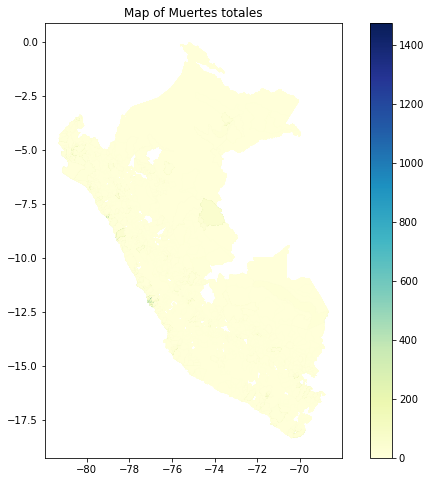

In [25]:
# Assuming 'geometry' is the geometry column in gdf
merged_gdf.plot(column="Muertes totales", cmap='YlGnBu', legend=True, figsize=(10, 8))
plt.title("Map of Muertes totales")
plt.show()